# Real-World Linkage Topology Designer

**An easy-to-use workflow for designing 3D-printable mechanical linkages**

---

## What this notebook does

You give it **periodic motion data for two rigid bodies** (e.g. a crank and a rocker, or two links in your mechanism).  The optimizer finds the best **two pin locations** on those bodies so that a **single rigid connecting link** can join them while maintaining nearly-constant distance over the entire motion cycle.

The output is a **3D-printable STL file** of that rigid connecting link, plus a JSON file with all the design parameters.

## How to use this notebook

1. **Run all cells from top to bottom** to understand the workflow
2. **Replace the motion data** in Section 2 with your own
3. **Adjust fabrication parameters** in Section 3 for your 3D printer & hardware
4. **Run the full pipeline** in Section 4
5. **Get your STL** and print it!

## What you need to provide

- **Motion data for Body A** — `(n_frames, 3)` array of `[theta_radians, world_x, world_y]` per frame
- **Motion data for Body B** — same format
- **Ground pivots** — where each body is pinned to the frame: `ground_a = (ax, ay)`, `ground_b = (bx, by)`
- **Motor axis** — where the driving force enters (usually body A's ground pivot)

## Important: unit system

The optimizer works in whatever units you provide.  If your motion data uses **millimeters**, set `unit_scale=1.0`.  If it uses meters, set `unit_scale=1000.0`.  The STL will be exported in millimeters.

## 0. Install dependencies (run once)

In [ ]:
# %pip install -q numpy scipy matplotlib pandas ipywidgets ipympl cma networkx trimesh shapely mapbox-earcut

## 1. Imports

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# The original research optimizer (must be in the same folder)
import linkage_topology_optimizer as lto

# The new user-friendly wrapper (must be in the same folder)
import real_world_linkage_runner as rwl

np.set_printoptions(precision=5, suppress=True)
plt.rcParams["figure.dpi"] = 120

print("✓ All imports ready.")

✓ All imports ready.


## 2. Define your motion data

**This is where you provide YOUR mechanism's motion.**  Choose ONE of the methods below:

### Option A: From raw arrays (most flexible)
If you have the states as numpy arrays from simulation, mocap, or hand-calculated data.

### Option B: From CSV files
If you exported motion data from CAD, simulation software, or a spreadsheet.

### Option C: Synthetic crank-rocker (for testing)
Generates a known four-bar mechanism.  The optimizer will try to *rediscover* the hidden coupler link.

In [4]:
# ═══════════════════════════════════════════════════════════════════
#  CHOOSE YOUR MOTION INPUT METHOD — uncomment ONE of the sections
# ═══════════════════════════════════════════════════════════════════

# ─── Option A: From raw arrays ─────────────────────────────────────
# Replace these arrays with your own data.
# Each row is [theta_radians, world_x, world_y]

# n_frames = 121
# times = np.linspace(0, 2*np.pi, n_frames, endpoint=False)
#
# # Body A (e.g. a crank): angle rotates, position fixed at origin
# my_states_a = np.column_stack([
#     times,                          # theta: 0 → 2π
#     np.full(n_frames, 0.0),         # x: fixed at 0
#     np.full(n_frames, 0.0),         # y: fixed at 0
# ])
#
# # Body B (e.g. a rocker): you need to compute these from your kinematics
# # This is a placeholder — replace with real data!
# my_states_b = np.column_stack([
#     np.linspace(1.8, 2.6, n_frames),  # theta: oscillates
#     np.full(n_frames, 80.0),           # x: fixed at ground_b
#     np.full(n_frames, 0.0),            # y: fixed at ground_b
# ])
#
# my_ground_a = (0.0, 0.0)
# my_ground_b = (80.0, 0.0)
# my_motor_axis = (0.0, 0.0)   # motor drives body A from origin
#
# motion = rwl.create_motion_from_arrays(
#     states_a=my_states_a,
#     states_b=my_states_b,
#     ground_a=my_ground_a,
#     ground_b=my_ground_b,
#     motor_positions=None,   # will auto-use ground_a repeated
#     times=times,
#     label="my_mechanism",
# )

# ─── Option B: From CSV files ───────────────────────────────────────
# Each CSV should have columns: theta, x, y  (reorderable via 'columns' param)
#
# motion = rwl.load_motion_from_csv(
#     path_a="path/to/body_a.csv",
#     path_b="path/to/body_b.csv",
#     ground_a=(0.0, 0.0),
#     ground_b=(80.0, 0.0),
#     motor_positions_path=None,   # optional, defaults to ground_a
#     delimiter=",",
#     skip_header=1,   # skip CSV header row
#     columns=(0, 1, 2),   # column order: theta, x, y
#     label="my_csv_motion",
# )

# ─── Option C: Synthetic crank-rocker (for testing) ─────────────────
# This generates motion from a known 4-bar.  The optimizer will try
# to rediscover the hidden coupler link.

motion = rwl.create_crank_rocker_motion(
    ground_a=(0.0, 0.0),       # crank pivot (mm)
    ground_b=(80.0, 0.0),      # rocker pivot (mm)
    crank_radius=25.0,         # crank length (mm)
    rocker_radius=55.0,        # rocker length (mm)
    coupler_length=62.5,       # hidden coupler length (mm)
    n_samples=121,
)

# ─── Verify the motion data ─────────────────────────────────────────
print(f"Motion: {motion.label}")
print(f"  Frames:  {motion.n_frames}")
print(f"  Scale:   {motion.characteristic_length:.1f} units")
print(f"  Ground A: {motion.ground_a}")
print(f"  Ground B: {motion.ground_b}")
print(f"  States A shape: {motion.states_a.shape}")
print(f"  States B shape: {motion.states_b.shape}")

Motion: crank_rocker_25.0_55.0_62.5
  Frames:  121
  Scale:   80.0 units
  Ground A: [0. 0.]
  Ground B: [80.  0.]
  States A shape: (121, 3)
  States B shape: (121, 3)


In [5]:
# Preview the motion: show body outlines at sampled phases
motion.target_states.shape  # should be (n_frames, 2, 3)

(121, 2, 3)

## 2b. Define body geometry (optional)

You can customize the visual outline of each body.  This is used for:
- Plots (visualizing the mechanism)
- Marker tracking during CMA-ES refinement
- Bone-segment alignment penalty

If you skip this, reasonable defaults are created automatically.

In [6]:
# Customize these for your real mechanism!
# The outline is a polygon in local coordinates (origin at the ground pivot)

body_specs = [
    rwl.BodySpec(
        name="crank",
        outline=np.array([
            [0.0, -3.0],   # a simple rectangle
            [25.0, -3.0],
            [25.0, 3.0],
            [0.0, 3.0],
        ]),
        markers={
            "tip": np.array([25.0, 0.0]),          # endpoint marker
            "mid": np.array([12.5, 0.0]),          # midpoint marker
        },
    ),
    rwl.BodySpec(
        name="rocker",
        outline=np.array([
            [0.0, -4.0],
            [55.0, -4.0],
            [55.0, 4.0],
            [0.0, 4.0],
        ]),
        markers={
            "tip": np.array([55.0, 0.0]),
            "output_point": np.array([46.0, 8.0]),  # a point you care about
        },
    ),
]

# Preview the body geometry
for bs in body_specs:
    print(f"Body '{bs.name}': outline={bs.outline.shape[0]} vertices, "
          f"markers={list(bs.markers.keys())}")

Body 'crank': outline=4 vertices, markers=['tip', 'mid']
Body 'rocker': outline=4 vertices, markers=['tip', 'output_point']


## 3. Set design parameters

These control the optimization quality, speed, and fabrication output.

### Key parameters to adjust:

| Parameter | Default | What it does |
|-----------|---------|-------------|
| `n_starts` | 80 | Multi-start count — higher = more thorough search |
| `n_candidates` | 8 | Distinct designs to return |
| `cma_max_iterations` | 50 | CMA-ES generations — more = better refinement |
| `cma_time_stride` | 3 | Subsample for speed; set to 1 for final run |
| `fabrication_thickness` | 3.0 | Link thickness in **mm** |
| `fabrication_width` | 5.0 | Link width in **mm** |
| `hole_radius` | 2.0 | Pin hole radius in **mm** |
| `unit_scale` | 1.0 | Abstract units per mm. Set to 1.0 if your data is in mm |
| `bend_fraction` | 0.08 | How much the link bends (0 = straight bar) |

In [7]:
params = rwl.DesignParameters(
    # ── Topology search ──────────────────────────────────
    n_starts=80,                # more starts = more thorough but slower
    n_candidates=8,             # how many distinct designs to find
    gamma=0.1,                  # moment-arm penalty weight
    coordinate_bound=None,      # auto-computed if None
    seed=7,                     # for reproducibility
    
    # ── CMA-ES refinement ────────────────────────────────
    cma_max_iterations=30,      # increase to 80-200 for final run
    cma_time_stride=3,          # set to 1 for highest accuracy
    cma_sigma0=0.10,            # initial search radius
    
    # ── 3D printing ──────────────────────────────────────
    fabrication_thickness=3.0,  # mm — link thickness
    fabrication_width=5.0,      # mm — link width
    hole_radius=2.0,            # mm — pin hole radius (match your pins!)
    unit_scale=1.0,             # 1.0 if your data is in mm
    
    # ── Organic shape ────────────────────────────────────
    bend_fraction=0.08,         # link curvature; 0 = straight
    tangent_fraction=0.18,      # tangent handle length
)

print("✓ Parameters configured.")
print(f"  Fab: {params.fabrication_thickness}mm thick, {params.fabrication_width}mm wide, "
      f"{params.hole_radius}mm holes")

✓ Parameters configured.
  Fab: 3.0mm thick, 5.0mm wide, 2.0mm holes


## 4. Run the full pipeline

This does everything:
1. Analytic topology optimization (Newton multi-start)
2. Forward kinematics simulation
3. CMA-ES global refinement
4. Organic link centerline shaping
5. STL + JSON export

**⚠ This takes 1-5 minutes** depending on `n_starts` and `cma_max_iterations`.

[1/5] Building analytic topology objective ...
    Derivative check: gradient err=1.12e-09, Hessian err=1.49e-09
[2/5] Multi-start Newton search (80 starts) ...
    Found 8 candidates. Best: q_a=[25.01084  0.00522], q_b=[55.01674 -0.12472], L=62.615, CV=1.53e-04
[3/5] Forward kinematics simulation ...
    Converged: 100.0%, max residual: 4.72e-08
[4/5] CMA-ES refinement (30 generations) ...
    Best cost: 1.240056e-04, params: [24.99348  0.02834 55.03625 -0.21627]
[5/5] Shaping organic link + exporting STL/JSON ...
    STL  → my_linkage_output\crank_rocker_25.0_55.0_62.5_link.stl
    JSON → my_linkage_output\crank_rocker_25.0_55.0_62.5_design.json


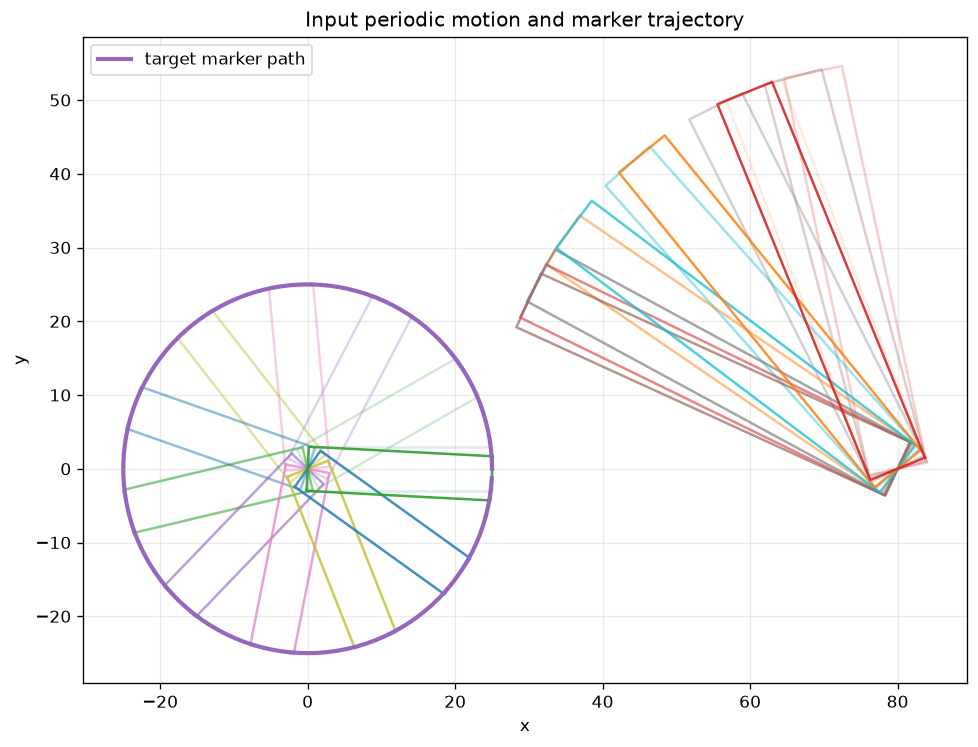

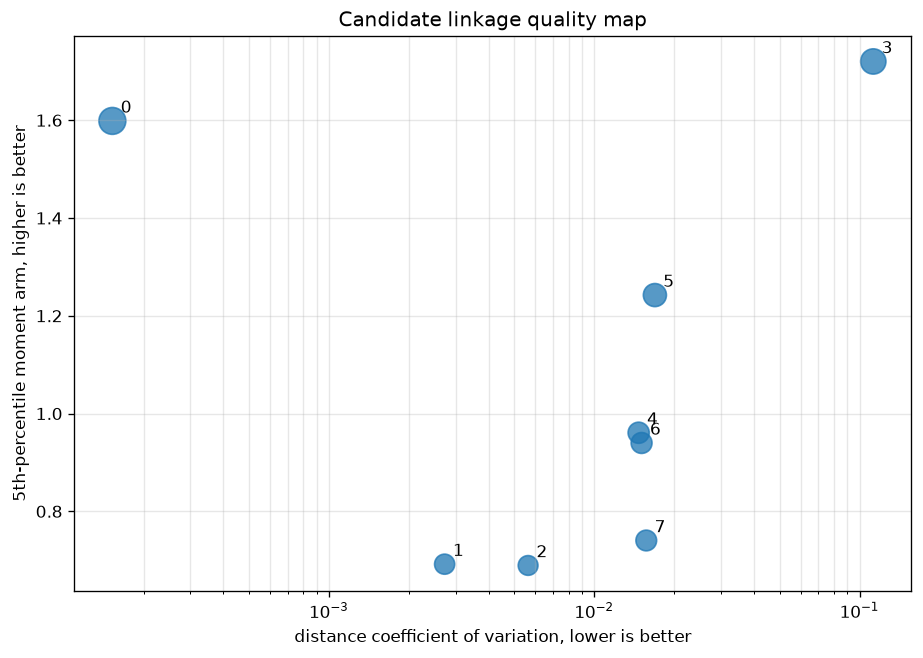

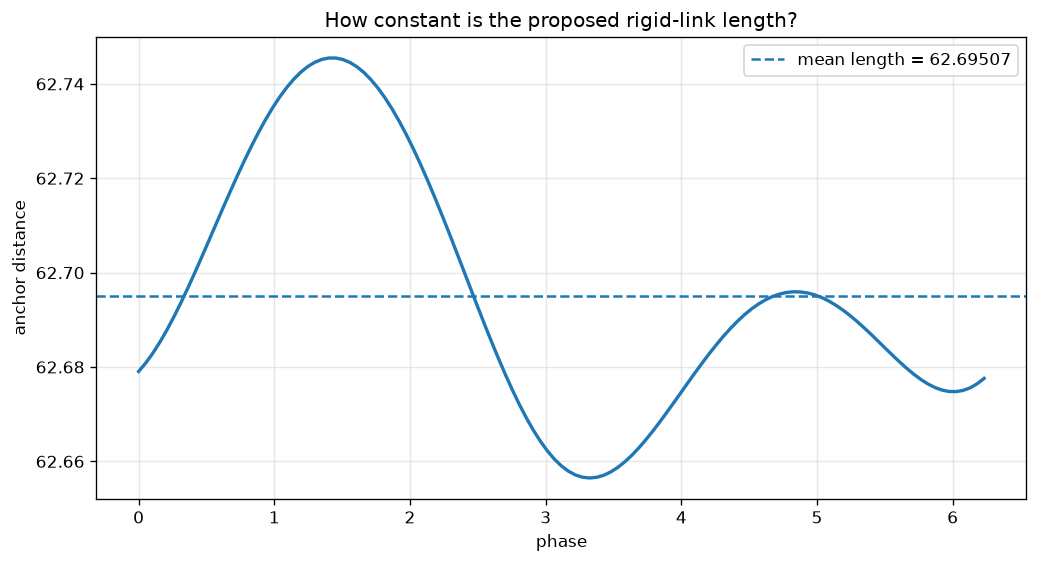

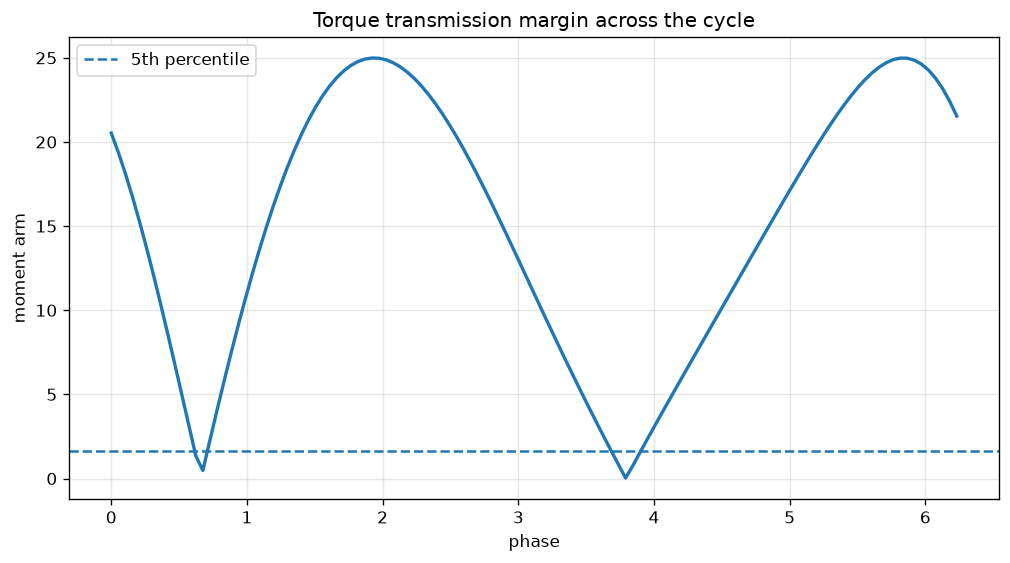

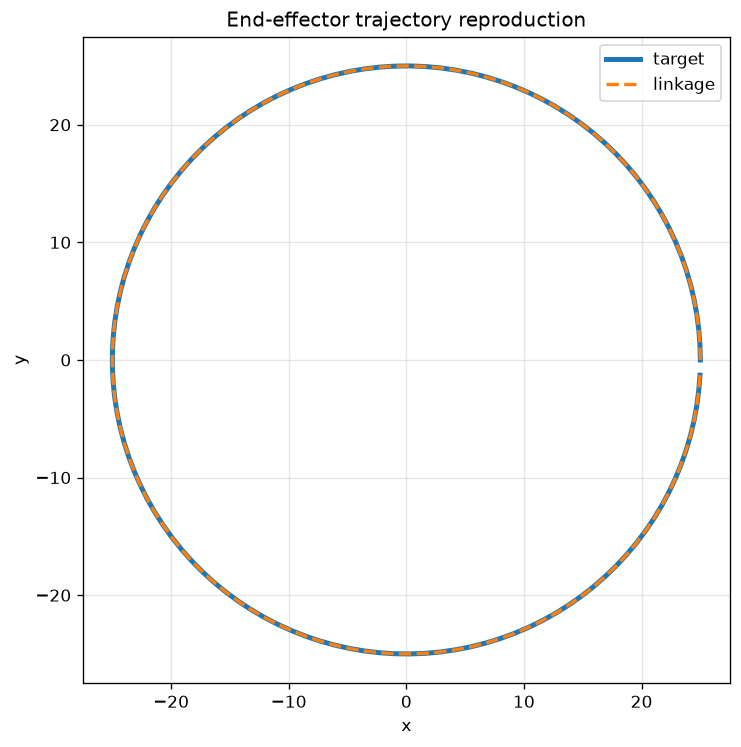

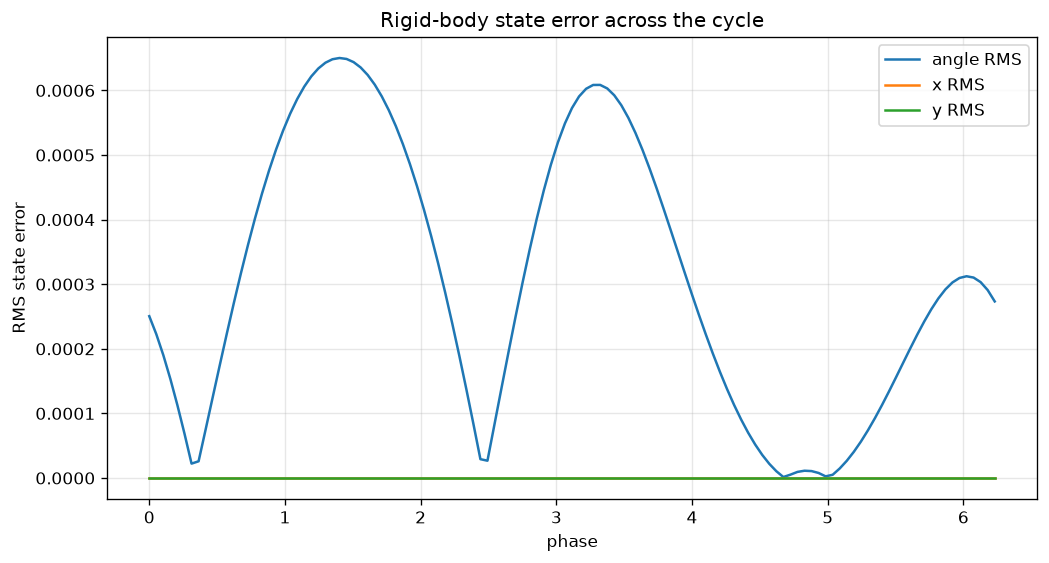

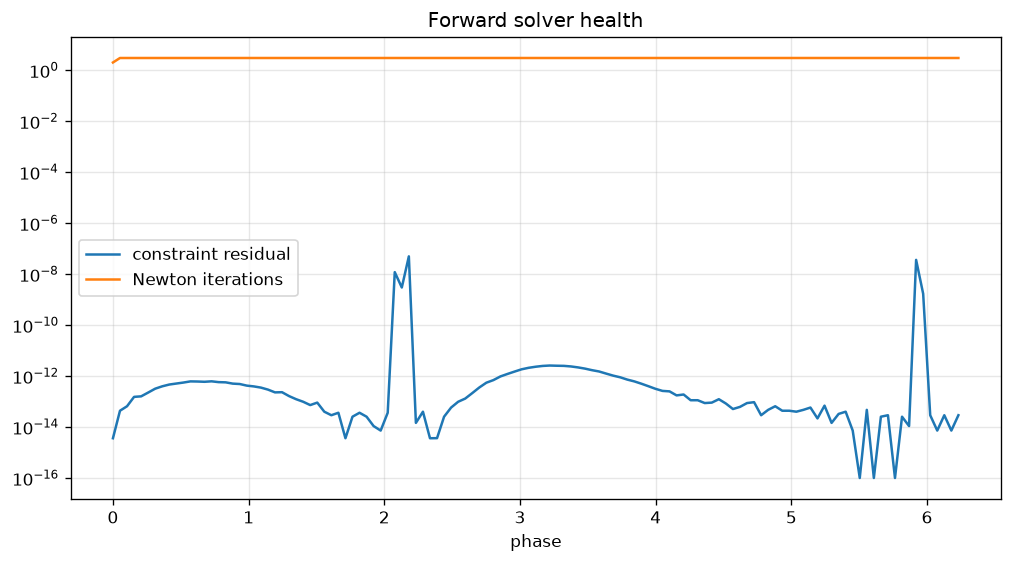

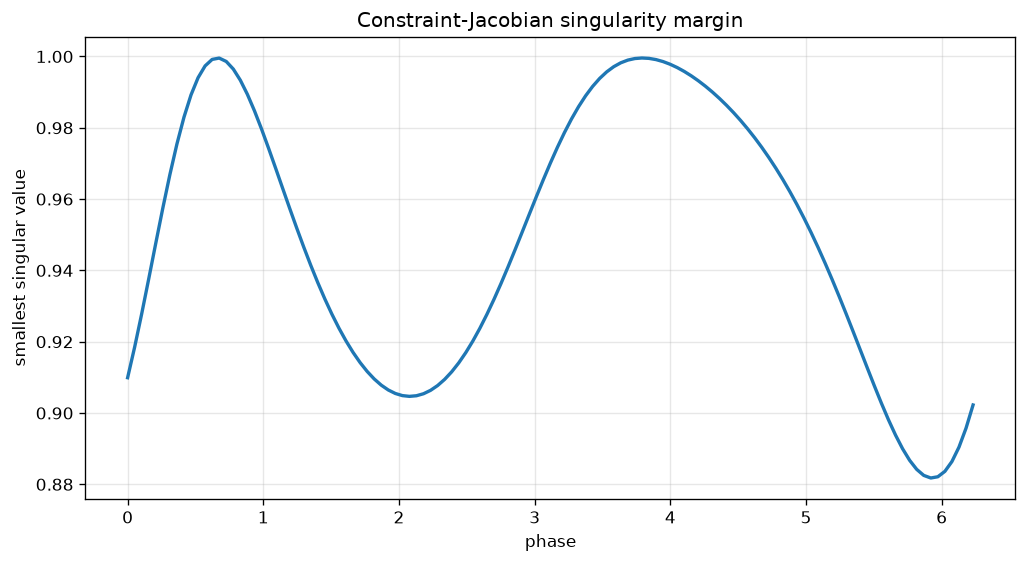

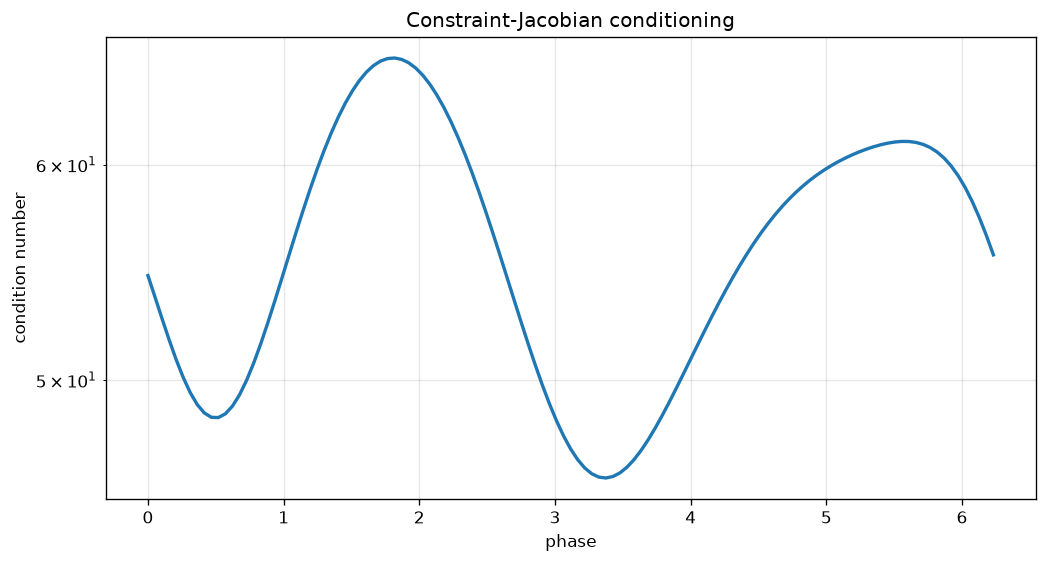

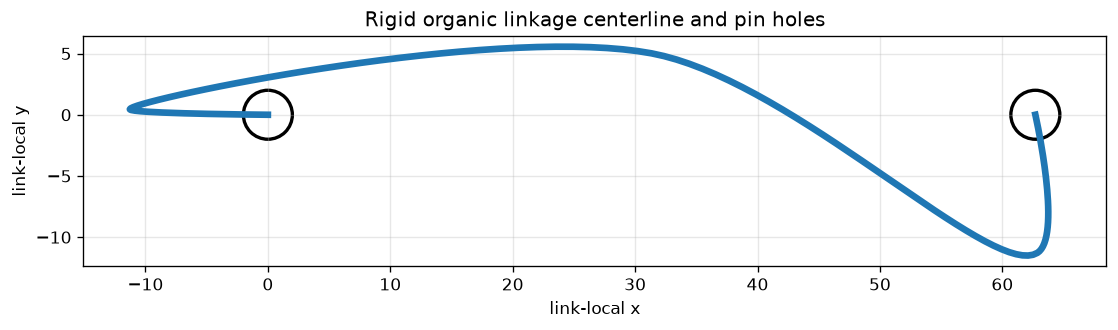

In [7]:
output_dir = Path("./my_linkage_output")

result = rwl.run_linkage_design(
    motion=motion,
    body_specs=body_specs,
    params=params,
    output_dir=output_dir,
    make_plots=True,
    verbose=True,
)

## 5. Review the results

In [8]:
print(result.summary())

  LINKAGE DESIGN RESULT
  Motion:       crank_rocker_25.0_55.0_62.5 (121 frames)
  Pin A:        q_a = [24.993, 0.028]
  Pin B:        q_b = [55.036, -0.216]
  Link length:  62.695 abstract units
  Dist CV:      4.22e-04
  P05 mom.arm:  1.609
  Min mom.arm:  0.031
  Converged:    True
──────────────────────────────────────────────────────────
  Fab thickness:3.0 mm
  Fab width:    5.0 mm
  Hole radius:  2.00 mm
  Unit scale:   1.000 abs/mm
──────────────────────────────────────────────────────────
  STL:          my_linkage_output\crank_rocker_25.0_55.0_62.5_link.stl
  JSON:         my_linkage_output\crank_rocker_25.0_55.0_62.5_design.json


In [8]:
# View all candidates sorted by quality
candidate_df = lto.candidate_table(result.candidates)
candidate_df

NameError: name 'result' is not defined

## 6. Interactive inspection (JupyterLab only)

Drag the slider to step through the motion cycle and verify the linkage works.

In [ ]:
# Interactive phase viewer
lto.interactive_phase_viewer(
    result.components,
    result.simulation.states,
    q_a=result.best_candidate.q_a,
    q_b=result.best_candidate.q_b,
    motor_positions=motion.motor_positions,
    target_states=motion.target_states,
)

## 7. Output files

Your STL and JSON files are ready in the output directory.

In [1]:
print(f"STL:  {result.stl_path}")
print(f"JSON: {result.json_path}")

# Read back the JSON to see what's inside
import json
with open(result.json_path, "r") as f:
    design_data = json.load(f)
print("\nJSON contents:")
print(json.dumps(design_data, indent=2))

NameError: name 'result' is not defined

## 8. Tips for real-world use

### Getting good results

- **More starts = better solutions.**  Try `n_starts=200` for production runs.
- **CMA-ES is the final polish.**  Set `cma_max_iterations=100` and `cma_time_stride=1` for your final run.
- **Check the CV (coefficient of variation).**  Values below ~0.01 mean the link maintains nearly constant length.  Above ~0.05 means the motion may not be achievable with a single rigid link.
- **Check the moment arm.**  The 5th-percentile moment arm should be at least a few percent of the characteristic length.  Near-zero values mean the mechanism will bind at some phases.

### Inputting your own motion

Your motion data MUST be periodic — the start and end poses should match.  The optimizer assumes one full cycle.  If your motion is not periodic, the constraint solver may not converge.

### The `motor_positions` parameter

This defines the point used to compute the **moment arm** triangle.  It should be the axis about which the driving torque is applied.  For a crank-rocker:
- Set `motor_positions` to the **crank ground pivot** (repeated for every frame)
- The area of the triangle (motor → pin_A → pin_B) is the moment arm

### 3D printing notes

- The STL unit is **millimeters** (as exported by `unit_scale` conversion)
- Pin holes are circular cutouts at the centerline endpoints
- Print with at least 0.12 mm layer height for smooth pin bores
- Add **tolerance** to the hole radius (e.g. 0.1-0.2mm extra) for pin clearance
- The link is 2.5D — it lies flat in XY and is extruded in Z
- For a multi-link mechanism, use the `export_all_stls()` function to handle collision Z-layering

### Physical validation (as noted by the original authors)

Before fabrication, check: clearances, pin diameters, link thickness, bearing friction, backlash, motor torque, stress, deflection, print orientation, and tolerance accumulation.

## 9. Advanced: Multi-link mechanism

If you have more than two bodies connected by multiple links, you can:
1. Design each link separately with `run_linkage_design()`
2. Check for link-link collisions with `build_multi_link_trajectories()`
3. Assign Z-layers so links don't intersect
4. Export all STLs with proper Z offsets

Example (skeleton):
```python
# Design link 1 (body A → body B)
result_1 = rwl.run_linkage_design(motion_ab, ...)

# Design link 2 (body B → body C)
result_2 = rwl.run_linkage_design(motion_bc, ...)

# Collect designs
designs = {
    "link_ab": (motion_ab, result_1),
    "link_bc": (motion_bc, result_2),
}

# Assign layers & export all STLs
paths = rwl.export_all_stls(
    designs,
    output_dir="./multi_link_output",
    layer_spacing_mm=3.0,
)

## 10. Saving and loading motion data

Save your motion to JSON so you don't have to recompute it:

In [12]:
# Export motion to JSON for later use
import json

motion_json = {
    "states_a": motion.states_a.tolist(),
    "states_b": motion.states_b.tolist(),
    "ground_a": motion.ground_a.tolist(),
    "ground_b": motion.ground_b.tolist(),
    "motor_positions": motion.motor_positions.tolist(),
    "times": motion.times.tolist() if motion.times is not None else None,
}

save_path = Path("./my_motion_data.json")
save_path.write_text(json.dumps(motion_json, indent=2))
print(f"Saved motion data to {save_path}")

# Later, reload it:
# motion = rwl.load_motion_from_json("./my_motion_data.json", label="reloaded")

Saved motion data to my_motion_data.json


## 11. One-call shortcut

For quick iterations, use the `quick_design()` function:

In [13]:
# All-in-one call — override any DesignParameters:
# design = rwl.quick_design(
#     motion_data=motion,
#     ground_a=(0.0, 0.0),
#     ground_b=(80.0, 0.0),
#     motor_axis=(0.0, 0.0),
#     output_dir="./quick_output",
#     n_starts=120,
#     cma_max_iterations=60,
#     fabrication_thickness=4.0,
# )
# print(design.summary())